In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

##Loading the dataset

In [45]:
df=pd.read_csv("family_health_60day_dataset.csv")

In [46]:
df.head()

,family_member,age,gender,day_number,date,day_of_week,resting_heart_rate_bpm,spo2_percent,stress_score,steps,screen_time_hours,sleep_hours,medical_issue_flag_next_2_days
0,Aunt,42,F,1,18-05-2026,Monday,67.5,97.2,34.8,8612.0,5.00,6.90,0
1,Aunt,42,F,2,19-05-2026,Tuesday,68.0,97.0,31.5,9213.0,4.43,6.55,0
2,Aunt,42,F,3,20-05-2026,Wednesday,67.8,97.2,33.5,8404.0,4.01,6.73,0
3,Aunt,42,F,4,21-05-2026,Thursday,72.9,96.6,42.0,8900.0,5.34,7.68,0
4,Aunt,42,F,5,22-05-2026,Friday,65.1,97.2,34.3,5000.0,6.15,7.62,0


#Data Preprocessing

##Data understanding

In [47]:
df.shape

(603, 13)

In [48]:
df.columns

Index(['family_member', 'age', 'gender', 'day_number', 'date', 'day_of_week',
       'resting_heart_rate_bpm', 'spo2_percent', 'stress_score', 'steps',
       'screen_time_hours', 'sleep_hours', 'medical_issue_flag_next_2_days'],
      dtype='object')

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   family_member                   603 non-null    object 
 1   age                             603 non-null    int64  
 2   gender                          603 non-null    object 
 3   day_number                      603 non-null    int64  
 4   date                            603 non-null    object 
 5   day_of_week                     603 non-null    object 
 6   resting_heart_rate_bpm          603 non-null    float64
 7   spo2_percent                    596 non-null    float64
 8   stress_score                    599 non-null    float64
 9   steps                           598 non-null    float64
 10  screen_time_hours               597 non-null    float64
 11  sleep_hours                     599 non-null    float64
 12  medical_issue_flag_next_2_days  603 

In [50]:
df['date'] = pd.to_datetime(df['date'])

/tmp/ipykernel_11839/3532345252.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


In [51]:
df.isnull().sum()

,0
family_member,0
age,0
gender,0
day_number,0
date,0
day_of_week,0
resting_heart_rate_bpm,0
spo2_percent,7
stress_score,4
steps,5


In [52]:
df.duplicated().sum()

np.int64(3)

In [53]:
df.describe()

,age,day_number,date,resting_heart_rate_bpm,spo2_percent,stress_score,steps,screen_time_hours,sleep_hours,medical_issue_flag_next_2_days
count,603.000000,603.000000,603,603.000000,596.000000,599.000000,598.000000,597.000000,599.000000,603.000000
mean,40.769486,30.495854,2026-06-16 11:54:01.791044608,71.903483,96.967282,43.731553,6328.775920,6.149883,6.402053,0.159204
min,13.000000,1.000000,2026-05-18 00:00:00,52.800000,0.000000,7.500000,-389.000000,-1.000000,3.860000,0.000000
25%,20.000000,15.500000,2026-06-01 12:00:00,67.650000,96.800000,33.600000,4264.250000,4.950000,5.795000,0.000000
50%,42.000000,31.000000,2026-06-17 00:00:00,71.600000,97.500000,44.100000,5535.000000,6.030000,6.390000,0.000000
75%,50.000000,45.000000,2026-07-01 00:00:00,75.400000,98.000000,53.600000,8239.500000,7.340000,7.050000,0.000000
max,78.000000,60.000000,2026-07-16 00:00:00,250.000000,99.400000,84.300000,14936.000000,10.360000,8.420000,1.000000
std,21.810531,17.316899,NaN,13.044826,5.720779,13.994947,3001.032057,1.766514,0.869692,0.366170


### Checking Categorical Columns

In [54]:
df['gender'].value_counts()

,count
gender,
F,302
M,301


In [55]:
df['day_of_week'].value_counts()

,count
day_of_week,
Tuesday,91
Thursday,91
Monday,90
Wednesday,90
Saturday,81
Friday,80
Sunday,80


In [56]:
df['family_member'].value_counts()

,count
family_member,
Aunt,62
Brother-1,61
Brother-2,60
Father,60
Grandfather,60
Grandmother,60
Mother,60
Sister-1,60
Sister-2,60


In [57]:
df.sort_values(
    ['family_member', 'date']
).head(20)

,family_member,age,gender,day_number,date,day_of_week,resting_heart_rate_bpm,spo2_percent,stress_score,steps,screen_time_hours,sleep_hours,medical_issue_flag_next_2_days
0,Aunt,42,F,1,2026-05-18,Monday,67.5,97.2,34.8,8612.0,5.00,6.90,0
1,Aunt,42,F,2,2026-05-19,Tuesday,68.0,97.0,31.5,9213.0,4.43,6.55,0
2,Aunt,42,F,3,2026-05-20,Wednesday,67.8,97.2,33.5,8404.0,4.01,6.73,0
3,Aunt,42,F,4,2026-05-21,Thursday,72.9,96.6,42.0,8900.0,5.34,7.68,0
4,Aunt,42,F,5,2026-05-22,Friday,65.1,97.2,34.3,5000.0,6.15,7.62,0
5,Aunt,42,F,6,2026-05-23,Saturday,65.3,97.7,19.8,8724.0,4.94,6.23,1
6,Aunt,42,F,7,2026-05-24,Sunday,64.7,96.8,10.4,3000.0,5.64,6.44,1
7,Aunt,42,F,8,2026-05-25,Monday,220.0,97.4,10.1,8168.0,5.29,7.74,0
8,Aunt,42,F,9,2026-05-26,Tuesday,63.6,98.2,9.5,7851.0,5.40,7.19,0
9,Aunt,42,F,10,2026-05-27,Wednesday,68.7,97.7,18.4,9264.0,5.54,5.97,0


##Dealing with the bad data

In [58]:
df.drop_duplicates(ignore_index=True,inplace=True)

In [59]:
df['spo2_percent'] = df['spo2_percent'].fillna(df['spo2_percent'].median())
df['stress_score'] = df['stress_score'].fillna(df['stress_score'].median())
df['screen_time_hours'] = df['screen_time_hours'].fillna(df['screen_time_hours'].median())
df['sleep_hours'] = df['sleep_hours'].fillna(df['sleep_hours'].median())
df['steps'] = df['steps'].fillna(df['steps'].median())

#EDA

##Univariate Analysis

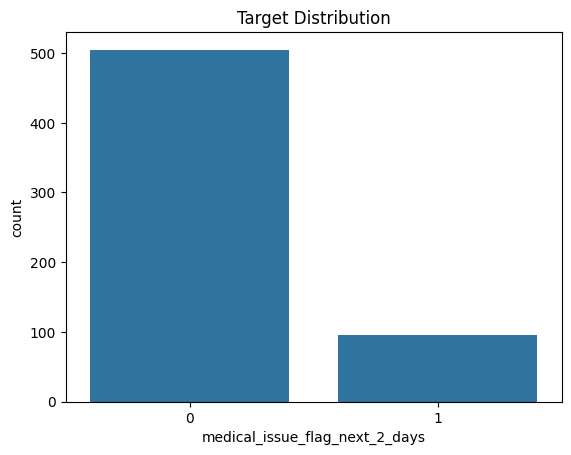

In [60]:
sns.countplot(x='medical_issue_flag_next_2_days', data=df)
plt.title('Target Distribution')
plt.show()

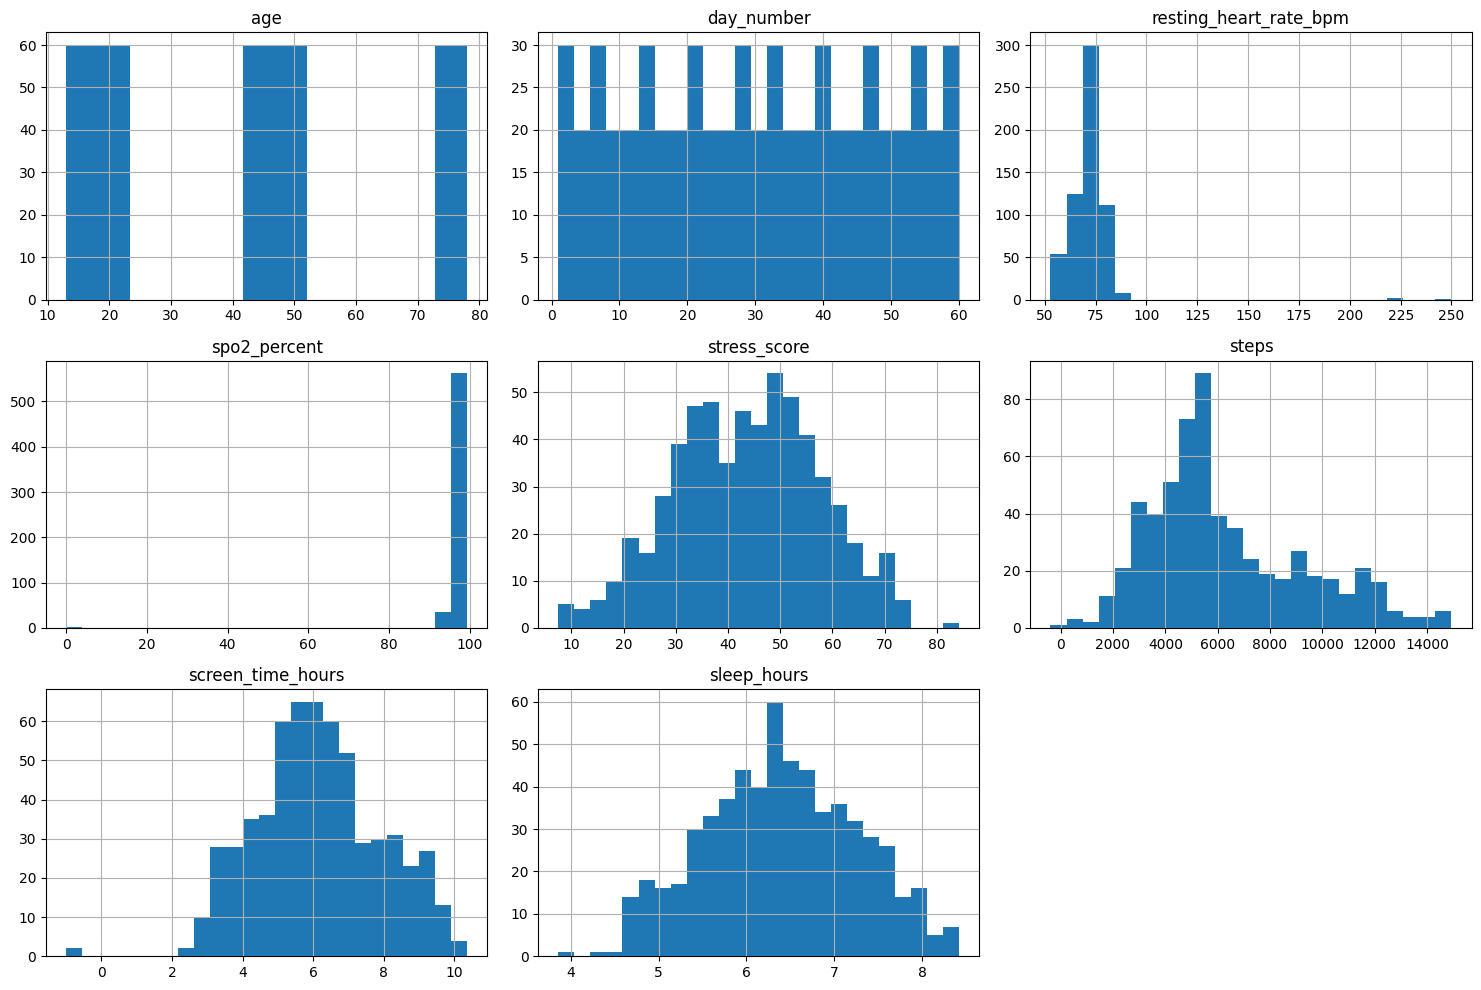

In [61]:
numeric_cols = [
    'age',
    'day_number',
    'resting_heart_rate_bpm',
    'spo2_percent',
    'stress_score',
    'steps',
    'screen_time_hours',
    'sleep_hours'
]
df[numeric_cols].hist(figsize=(15,10),bins=25)
plt.tight_layout()
plt.show()

##Bivariate Analysis

###Stress

Text(0.5, 1.0, 'Stress Score vs Medical Issue Flag')

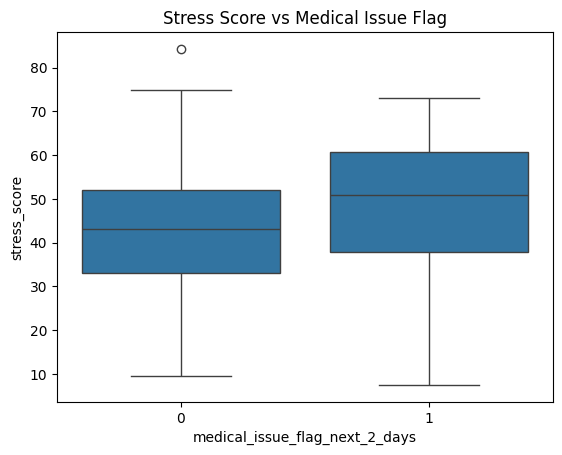

In [62]:
sns.boxplot(
    x='medical_issue_flag_next_2_days',
    y='stress_score',
    data=df
)

plt.title('Stress Score vs Medical Issue Flag')


###Sleep

Text(0.5, 1.0, 'Sleep Hours vs Medical Issue Flag')

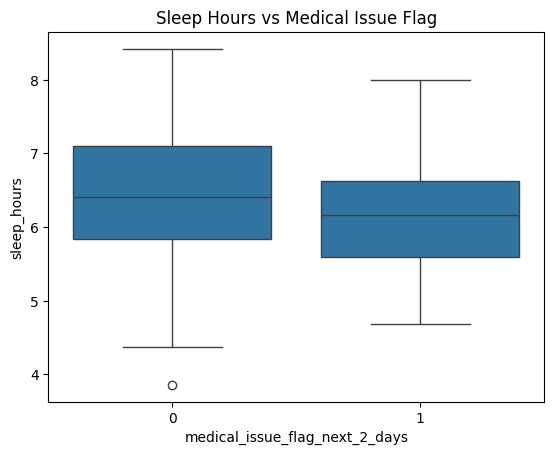

In [63]:
sns.boxplot(
    x='medical_issue_flag_next_2_days',
    y='sleep_hours',
    data=df
)
plt.title('Sleep Hours vs Medical Issue Flag')


###Heart Rate

Text(0.5, 1.0, 'Resting Heart Rate vs Medical Issue Flag')

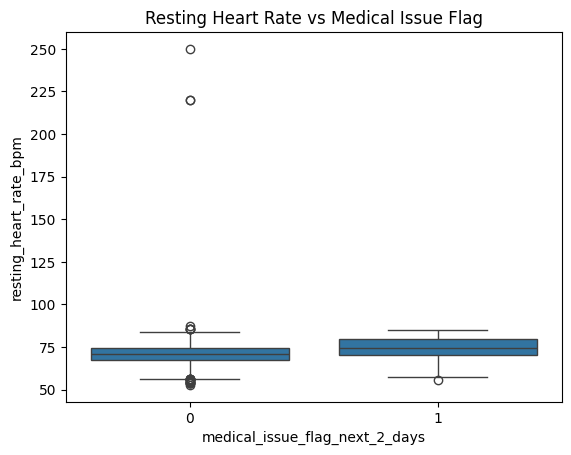

In [64]:
sns.boxplot(
    x='medical_issue_flag_next_2_days',
    y='resting_heart_rate_bpm',
    data=df
)

plt.title('Resting Heart Rate vs Medical Issue Flag')


###SpO2

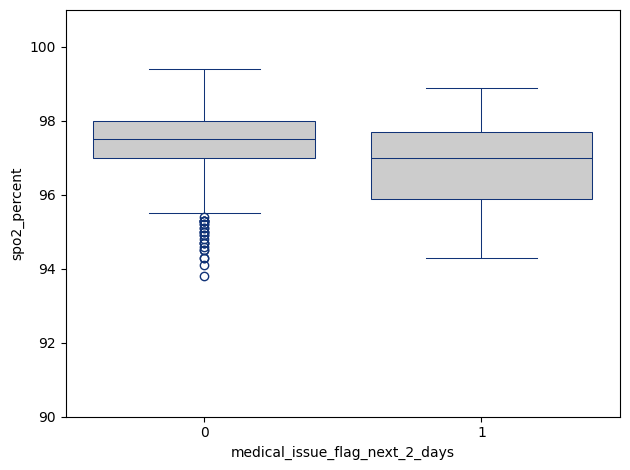

In [65]:
sns.boxplot(x='medical_issue_flag_next_2_days',
            y="spo2_percent",
            color=".8", linecolor="#137", linewidth=.75,
            data=df
)
plt.ylim(90, 101)
plt.tight_layout()

###Steps

Text(0.5, 1.0, 'Steps vs Medical Issue Flag')

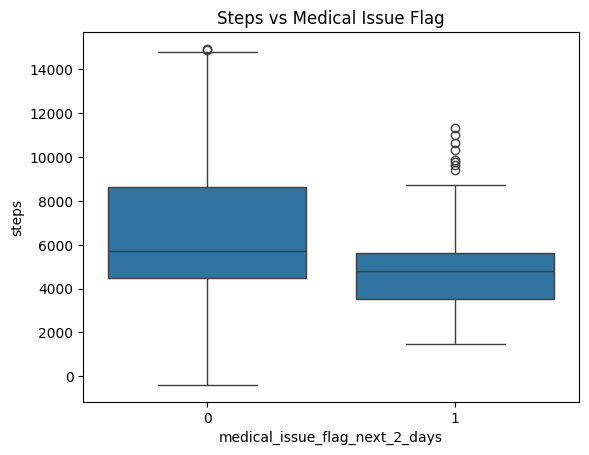

In [66]:
sns.boxplot(
    x='medical_issue_flag_next_2_days',
    y='steps',
    data=df
)

plt.title('Steps vs Medical Issue Flag')


###screen_time_hours

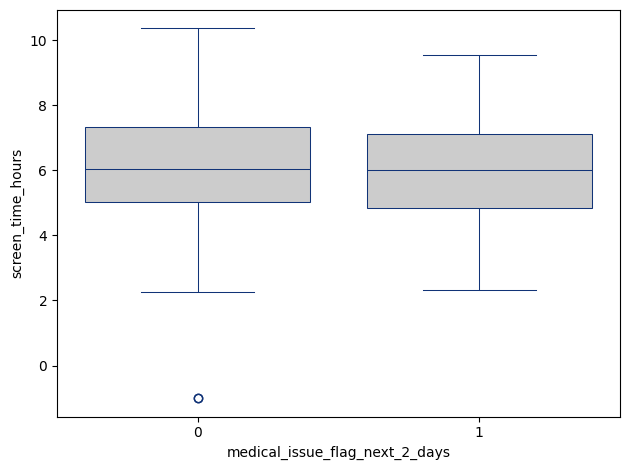

In [67]:
sns.boxplot(x='medical_issue_flag_next_2_days',
            y="screen_time_hours",
            color=".8", linecolor="#137", linewidth=.75,
            data=df
)
plt.tight_layout()

###Age

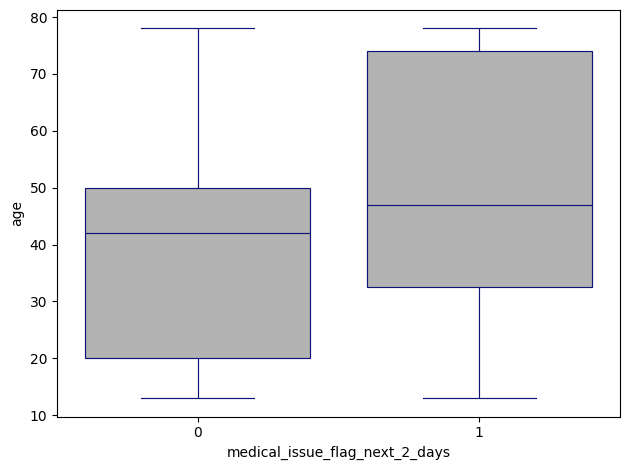

In [68]:
sns.boxplot(x='medical_issue_flag_next_2_days',
            y="age",
            color=".7", linecolor="#117", linewidth=.85,
            data=df
)
plt.tight_layout()

In [69]:
df.groupby('medical_issue_flag_next_2_days')[numeric_cols].mean()

,age,day_number,resting_heart_rate_bpm,spo2_percent,stress_score,steps,screen_time_hours,sleep_hours
medical_issue_flag_next_2_days,,,,,,,,
0,39.182178,31.354455,71.407525,97.183168,42.811287,6555.427723,6.169842,6.437614
1,49.400000,25.957895,74.793684,95.822105,49.080000,4970.484211,6.028211,6.170368


##Categorical Vs Target Analysis

###Gender

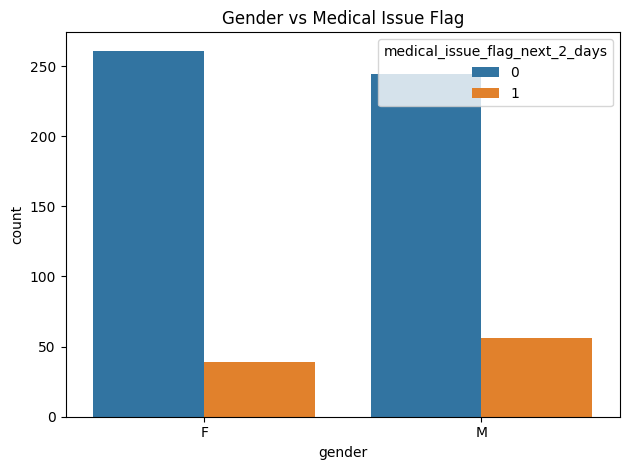

In [70]:
sns.countplot(
    x='gender',
    hue='medical_issue_flag_next_2_days',
    data=df
)

plt.title('Gender vs Medical Issue Flag')
plt.tight_layout()

###Day of week

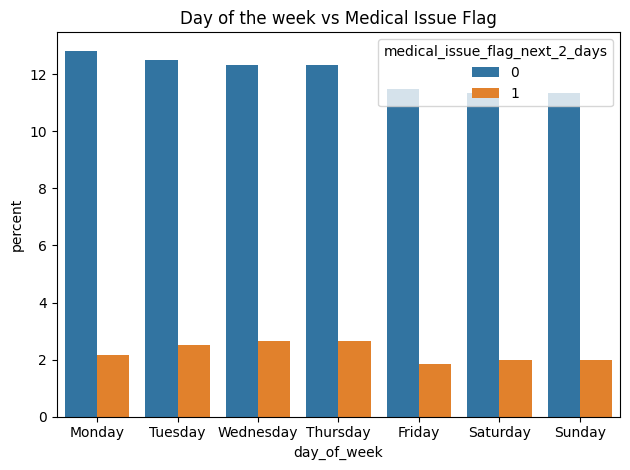

In [71]:
sns.countplot(
    x='day_of_week',
    hue='medical_issue_flag_next_2_days',
    stat="percent",
    data=df
)

plt.title('Day of the week vs Medical Issue Flag')
plt.tight_layout()

###Family Members

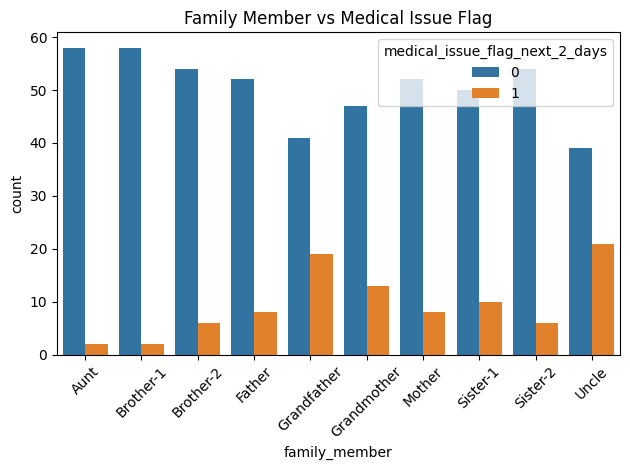

In [72]:
sns.countplot(
    x='family_member',
    hue='medical_issue_flag_next_2_days',
    data=df
)

plt.title('Family Member vs Medical Issue Flag')
plt.xticks(rotation=45)
plt.tight_layout()


##Correlation

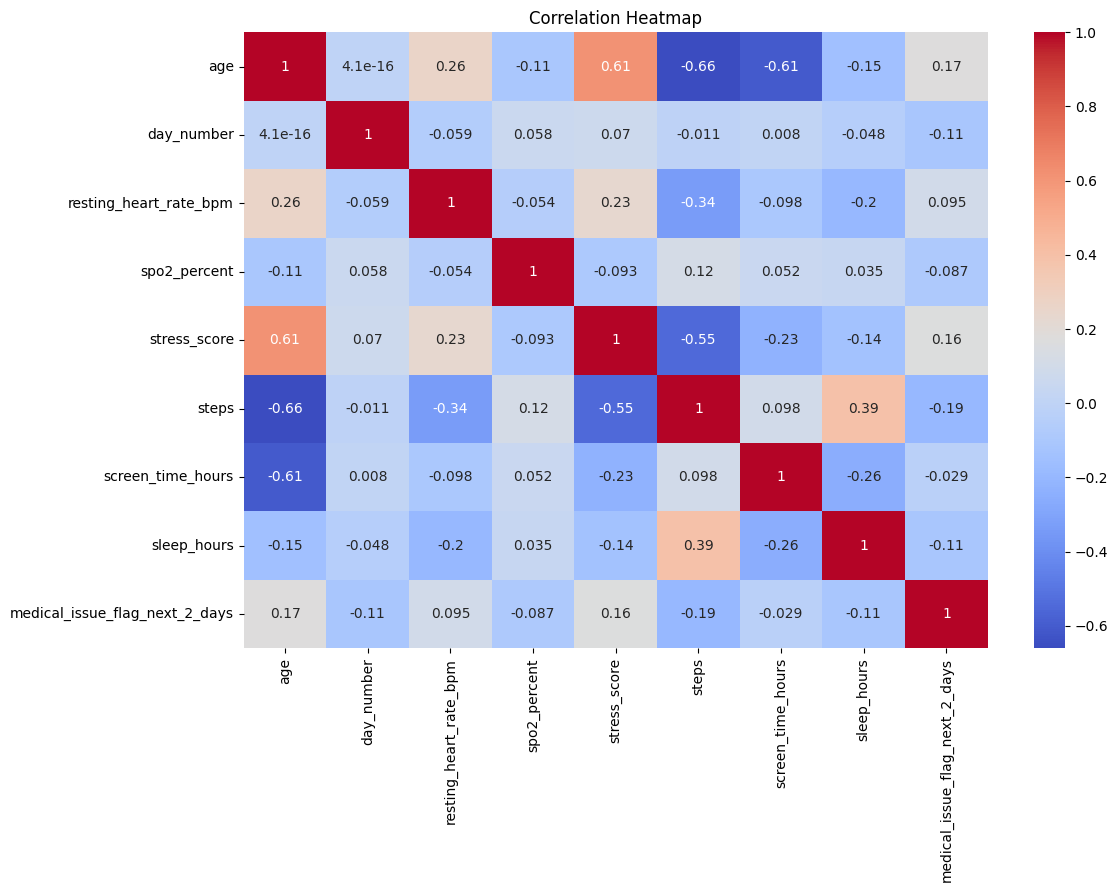

In [73]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[numeric_cols + ['medical_issue_flag_next_2_days']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

###Observations

--> Most numerical features show weak linear correlation with the target.

--> Age (0.17) and stress score (0.16) have weak positive correlations with the target.

--> Steps (-0.19) has the strongest negative correlation with the target among the numerical features.

-->Age has relatively strong relationships with stress (+0.61), steps (-0.66), and screen time (-0.61).

--> Stress and steps also show a moderate negative correlation (-0.55).


Since the correlations with the target are mostly weak, combinations of features may be more informative than individual features.


#Feature Engineering

In [74]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [75]:
df.columns

Index(['family_member', 'age', 'gender', 'day_number', 'date', 'day_of_week',
       'resting_heart_rate_bpm', 'spo2_percent', 'stress_score', 'steps',
       'screen_time_hours', 'sleep_hours', 'medical_issue_flag_next_2_days',
       'year', 'month', 'day'],
      dtype='object')

##OHE

In [76]:
df = pd.get_dummies(
    df,
    columns=['gender', 'day_of_week'],
    drop_first=True,
    dtype=int
)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   family_member                   600 non-null    object        
 1   age                             600 non-null    int64         
 2   day_number                      600 non-null    int64         
 3   date                            600 non-null    datetime64[ns]
 4   resting_heart_rate_bpm          600 non-null    float64       
 5   spo2_percent                    600 non-null    float64       
 6   stress_score                    600 non-null    float64       
 7   steps                           600 non-null    float64       
 8   screen_time_hours               600 non-null    float64       
 9   sleep_hours                     600 non-null    float64       
 10  medical_issue_flag_next_2_days  600 non-null    int64         
 11  year  

#Train_Test_Split

In [78]:
df = df.sort_values(['family_member', 'date'])

##Grouping the data based on the columns : Family Member, Date

In [79]:
train_list = []
test_list = []

for member, group in df.groupby('family_member'):

    group = group.sort_values('date')

    split_index = int(len(group) * 0.8)

    train_list.append(group.iloc[:split_index])
    test_list.append(group.iloc[split_index:])

train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

##Splitting the Dataset

In [80]:
target = 'medical_issue_flag_next_2_days'

X_train = train_df.drop(columns=[target, 'family_member', 'date','day_number'])
y_train = train_df[target]

X_test = test_df.drop(columns=[target, 'family_member', 'date','day_number'])
y_test = test_df[target]

In [81]:
X_test.columns

Index(['age', 'resting_heart_rate_bpm', 'spo2_percent', 'stress_score',
       'steps', 'screen_time_hours', 'sleep_hours', 'year', 'month', 'day',
       'gender_M', 'day_of_week_Monday', 'day_of_week_Saturday',
       'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday',
       'day_of_week_Wednesday'],
      dtype='object')

#Scaling

In [82]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()

X_train=scalar.fit_transform(X_train)
X_test=scalar.transform(X_test)

In [83]:
X_test

array([[ 0.05496958,  0.03433317,  0.17410633, ..., -0.41319694,
        -0.41319694, -0.41319694],
       [ 0.05496958, -0.5149975 ,  0.07951545, ..., -0.41319694,
        -0.41319694, -0.41319694],
       [ 0.05496958, -0.31780188,  0.0952806 , ..., -0.41319694,
         2.42015348, -0.41319694],
       ...,
       [ 0.19239354,  0.52732223, -0.26731775, ..., -0.41319694,
         2.42015348, -0.41319694],
       [ 0.19239354,  0.38646821, -0.39343892, ..., -0.41319694,
        -0.41319694,  2.42015348],
       [ 0.19239354,  0.46393792, -0.40920406, ...,  2.42015348,
        -0.41319694, -0.41319694]])

#Model Training

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}


for name, model in models.items():

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, zero_division=0)
    train_recall = recall_score(y_train, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
    train_roc_auc = roc_auc_score(y_train, y_train_prob)

    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
    test_roc_auc = roc_auc_score(y_test, y_test_prob)

    print(f"\n{name}")

    print("Training Results")
    print(f"Accuracy  : {train_accuracy:.4f}")
    print(f"Precision : {train_precision:.4f}")
    print(f"Recall    : {train_recall:.4f}")
    print(f"F1 Score  : {train_f1:.4f}")
    print(f"ROC AUC   : {train_roc_auc:.4f}")

    print("-" * 50)

    print("Test Results")
    print(f"Accuracy  : {test_accuracy:.4f}")
    print(f"Precision : {test_precision:.4f}")
    print(f"Recall    : {test_recall:.4f}")
    print(f"F1 Score  : {test_f1:.4f}")
    print(f"ROC AUC   : {test_roc_auc:.4f}")

    print("=" * 60)


Logistic Regression
Training Results
Accuracy  : 0.8229
Precision : 1.0000
Recall    : 0.0116
F1 Score  : 0.0230
ROC AUC   : 0.7007
--------------------------------------------------
Test Results
Accuracy  : 0.9250
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
ROC AUC   : 0.6697

KNN
Training Results
Accuracy  : 0.8313
Precision : 0.6316
Recall    : 0.1395
F1 Score  : 0.2286
ROC AUC   : 0.8263
--------------------------------------------------
Test Results
Accuracy  : 0.9083
Precision : 0.2500
Recall    : 0.1111
F1 Score  : 0.1538
ROC AUC   : 0.6291

SVM
Training Results
Accuracy  : 0.8229
Precision : 1.0000
Recall    : 0.0116
F1 Score  : 0.0230
ROC AUC   : 0.9446
--------------------------------------------------
Test Results
Accuracy  : 0.9250
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
ROC AUC   : 0.7307

Decision Tree
Training Results
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC AUC   : 1.0000
-----------------------------

#Hyperparamter tuning

In [85]:
from sklearn.model_selection import GridSearchCV

models_params = {

    "Logistic Regression": {
        "model": LogisticRegression(
            max_iter=2000
        ),
        "params": {
            "C": [0.01, 0.1, 1, 10, 100],
            "solver": ["liblinear"],
            "class_weight": [None, "balanced"]
        }
    },


    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 9, 11, 15],
            "weights": ["uniform", "distance"],
            "p": [1, 2]
        }
    },


    "SVM": {
        "model": SVC(
            probability=True
        ),
        "params": {
            "C": [0.01, 0.1, 1, 10, 100],
            "kernel": ["linear", "rbf"],
            "gamma": ["scale", "auto"],
            "class_weight": [None, "balanced"]
        }
    },


    "Decision Tree": {
        "model": DecisionTreeClassifier(
            random_state=42
        ),
        "params": {
            "criterion": ["gini", "entropy"],
            "max_depth": [2, 3, 4, 5, 6, 8, 10],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 2, 5, 10],
            "class_weight": [None, "balanced"]
        }
    },


    "Random Forest": {
    "model": RandomForestClassifier(
        random_state=42
    ),
    "params": {
        "n_estimators": [100, 200],
        "max_depth": [5, 10, None],
        "min_samples_leaf": [1, 5],
        "class_weight": [None, "balanced"]
    }
},


    "Gradient Boosting": {
        "model": GradientBoostingClassifier(
            random_state=42
        ),
        "params": {
            "n_estimators": [50, 100, 150],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [1, 2, 3],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 5],
            "subsample": [0.8, 1.0]
        }
    }
}


best_models = {}

for name, config in models_params.items():

    print(f"\nTuning {name}  ---->")

    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    print(f"Best Parameters: {grid.best_params_}")
    print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")


for name, model in best_models.items():

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]



    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(
        y_train, y_train_pred, zero_division=0
    )
    train_recall = recall_score(
        y_train, y_train_pred, zero_division=0
    )
    train_f1 = f1_score(
        y_train, y_train_pred, zero_division=0
    )
    train_roc_auc = roc_auc_score(
        y_train, y_train_prob
    )


    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(
        y_test, y_test_pred, zero_division=0
    )
    test_recall = recall_score(
        y_test, y_test_pred, zero_division=0
    )
    test_f1 = f1_score(
        y_test, y_test_pred, zero_division=0
    )
    test_roc_auc = roc_auc_score(
        y_test, y_test_prob
    )


    print(f"\n{'=' * 60}")
    print(name)
    print(f"{'=' * 60}")

    print("\nTraining Results")
    print(f"Accuracy  : {train_accuracy:.4f}")
    print(f"Precision : {train_precision:.4f}")
    print(f"Recall    : {train_recall:.4f}")
    print(f"F1 Score  : {train_f1:.4f}")
    print(f"ROC AUC   : {train_roc_auc:.4f}")

    print("\nTest Results")
    print(f"Accuracy  : {test_accuracy:.4f}")
    print(f"Precision : {test_precision:.4f}")
    print(f"Recall    : {test_recall:.4f}")
    print(f"F1 Score  : {test_f1:.4f}")
    print(f"ROC AUC   : {test_roc_auc:.4f}")


Tuning Logistic Regression  ---->
Best Parameters: {'C': 0.01, 'class_weight': 'balanced', 'solver': 'liblinear'}
Best CV ROC-AUC: 0.5452

Tuning KNN  ---->
Best Parameters: {'n_neighbors': 15, 'p': 2, 'weights': 'uniform'}
Best CV ROC-AUC: 0.4771

Tuning SVM  ---->
Best Parameters: {'C': 0.01, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear'}
Best CV ROC-AUC: 0.5491

Tuning Decision Tree  ---->
Best Parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV ROC-AUC: 0.5646

Tuning Random Forest  ---->
Best Parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 200}
Best CV ROC-AUC: 0.4153

Tuning Gradient Boosting  ---->
Best Parameters: {'learning_rate': 0.01, 'max_depth': 2, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 50, 'subsample': 1.0}
Best CV ROC-AUC: 0.5153

Logistic Regression

Training Results
Accuracy  : 0.6146
Precision : 0

In [86]:
import pickle
from google.colab import files

final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

final_model.fit(X_train, y_train)

with open("random_forest_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

with open("scaler.pkl", "wb") as file:
    pickle.dump(scalar, file)


feature_columns = [
    'age',
    'gender_M',
    'day_of_week_Monday',
    'day_of_week_Saturday',
    'day_of_week_Sunday',
    'day_of_week_Thursday',
    'day_of_week_Tuesday',
    'day_of_week_Wednesday',
    'resting_heart_rate_bpm',
    'spo2_percent',
    'stress_score',
    'steps',
    'screen_time_hours',
    'sleep_hours'
]

with open("feature_columns.pkl", "wb") as file:
    pickle.dump(feature_columns, file)


files.download("random_forest_model.pkl")
files.download("scaler.pkl")
files.download("feature_columns.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All 3 files have been saved and downloaded successfully!
